In [ ]:
import os

# 1. Настройки путей и ID

file_id = '1C4V4pxywrtvC9Tbp_BxzIyLqXXKy1hUF'
# Имя файла, которое ожидает DeepFace
cache_name = 'ds_model_vggface_detector_opencv_aligned_normalization_base_expand_0.pkl'
destination = os.path.join('lfw-deepfunneled', cache_name)

# 2. Проверка папки (создаем, если unzip еще не был запущен)
if not os.path.exists('lfw-deepfunneled'):
    os.makedirs('lfw-deepfunneled')

# 3. Скачивание кэша с Google Диска
if not os.path.exists(destination):
    print("Загрузка готового кэша (500МБ) для мгновенного поиска...")
    # gdown скачивает файлы с Google Drive напрямую в систему
    !gdown --id {file_id} -O {destination}
    print("Кэш успешно загружен!")
else:
    print("Файл кэша уже на месте. Поиск будет быстрым.")

Файл кэша уже на месте. Поиск будет быстрым.


In [ ]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.2/169.2 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 5.4 MB/s eta 0:00:00


In [ ]:
import os

# 1. ID ZIP-архива
lfw_zip_id = '18HoV88Gj-tdaDs6F95xsaeTmeYXl5v0l'

# 2. Скачивание архива фотографий
if not os.path.exists("lfw-deepfunneled.zip"):
    print("Загрузка архива фотографий из облака...")
    !gdown --id {lfw_zip_id} -O lfw-deepfunneled.zip
else:
    print("Архив фотографий уже скачан.")

# 3. Распаковка архива
# Флаг -q делает распаковку тихой, а -d указывает папку назначения
if not os.path.exists("lfw-deepfunneled"):
    print("Распаковка фотографий (это может занять полминуты)...")
    !unzip -q lfw-deepfunneled.zip -d /content/
    print("Распаковка завершена. Папка lfw-deepfunneled готова к работе.")
else:
    # Если папка есть, но в ней только кэш, принудительно распакуем туда фото
    if len(os.listdir('lfw-deepfunneled')) < 10:
        print("Папка пуста, запускаю повторную распаковку...")
        !unzip -q -o lfw-deepfunneled.zip -d /content/
    print("База фотографий на месте.")

Загрузка архива фотографий из облака...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=18HoV88Gj-tdaDs6F95xsaeTmeYXl5v0l
From (redirected): https://drive.google.com/uc?id=18HoV88Gj-tdaDs6F95xsaeTmeYXl5v0l&confirm=t&uuid=c98b62ad-b3a5-4cdb-8b5e-3e3657531f97
To: /content/lfw-deepfunneled.zip
100% 118M/118M [00:02<00:00, 40.6MB/s]
Папка пуста, запускаю повторную распаковку...
База фотографий на месте.


In [ ]:
from google.colab import files
import os

# 1. Запрашиваем загрузку файла у пользователя
print("Пожалуйста, выберите ваше фото на компьютере:")
uploaded = files.upload()

# 2. Переименовываем загруженный файл в 'me.jpg' для стабильной работы кода
for filename in uploaded.keys():
    # Если загрузили несколько, возьмем первое
    os.rename(filename, 'me.jpg')
    print(f"Файл {filename} успешно загружен и переименован в me.jpg")
    break # Выходим из цикла после первого файла

Пожалуйста, выберите ваше фото на компьютере:


Saving me19.jpg to me19.jpg
Файл me19.jpg успешно загружен и переименован в me.jpg


Начинаю поиск в базе lfw-deepfunneled...
Начинаю мгновенный поиск в базе...
26-02-26 22:30:55 - Could be some changes in lfw-deepfunneled not tracked.Set refresh_database to true to assure that any changes will be tracked.
26-02-26 22:30:55 - Searching me.jpg in 14321 length datastore
26-02-26 22:31:03 - find function duration 12.84446668624878 seconds


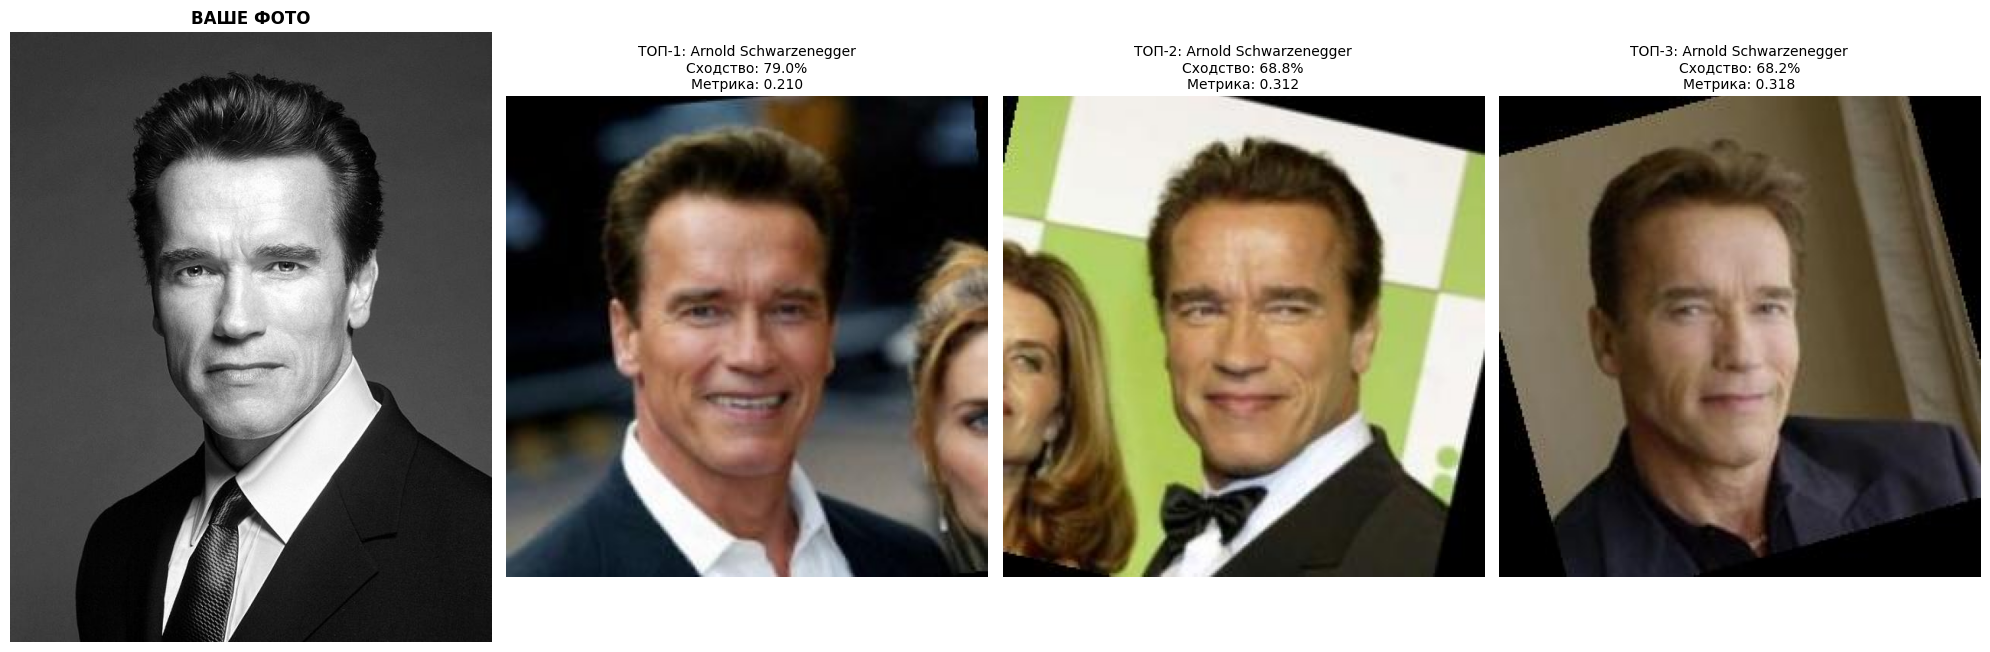

In [ ]:


from deepface import DeepFace
import os
import cv2
import matplotlib.pyplot as plt

# --- ШАГ 1: САМ ПОИСК ---
print("Начинаю поиск в базе lfw-deepfunneled...")
# Результат - это список датафреймов
print("Начинаю мгновенный поиск в базе...")

results = DeepFace.find(img_path = "me.jpg",
                        db_path = "lfw-deepfunneled",
                        model_name = "VGG-Face",
                        detector_backend = 'opencv',
                        enforce_detection = False,
                        refresh_database = False)

# --- ШАГ 2: ВИЗУАЛИЗАЦИЯ ---
if isinstance(results, list) and len(results) > 0:
    df = results[0] # Выбираем таблицу для первого найденного лица

    if not df.empty:
        # Умный поиск колонки с дистанцией (берем первое совпадение как строку)
        potential_cols = [c for c in df.columns if 'cosine' in c or 'distance' in c]
        dist_col = potential_cols[0] if potential_cols else df.columns[-1]

        # Сортируем (на всякий случай) и берем ТОП-3
        top_3 = df.sort_values(by=dist_col).head(3)

        plt.figure(figsize=(20, 8))

        # Отрисовка вашего фото
        plt.subplot(1, 4, 1)
        if os.path.exists("me.jpg"):
            my_img = cv2.cvtColor(cv2.imread("me.jpg"), cv2.COLOR_BGR2RGB)
            plt.imshow(my_img)
            plt.title("ВАШЕ ФОТО", fontsize=12, fontweight='bold')
        plt.axis('off')

        # Отрисовка двойников
        for i, (idx, row) in enumerate(top_3.iterrows()):
            img_path = row['identity']
            # Явно приводим к числу, чтобы не было ошибок с типами
            dist = float(row[dist_col])

            # Процент сходства
            similarity = (1 - dist) * 100
            if similarity < 0: similarity = 0

            plt.subplot(1, 4, i + 2)
            if os.path.exists(img_path):
                match_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
                plt.imshow(match_img)

            # Формируем имя из названия папки
            name = os.path.basename(os.path.dirname(img_path)).replace('_', ' ')
            plt.title(f"ТОП-{i+1}: {name}\nСходство: {similarity:.1f}%\nМетрика: {dist:.3f}", fontsize=10)
            plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("Совпадений в базе не найдено. Попробуйте другое фото или уменьшите строгость.")
else:
    print("Ошибка: нейросеть не вернула результатов. Проверьте me.jpg и базу.")